In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix, classification_report, recall_score

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

Device : cpu


In [3]:
df_train_2018 = pd.read_parquet('../data/processed/2018/2018_train_scaled.parquet')
df_test_2018  = pd.read_parquet('../data/processed/2018/2018_test_scaled.parquet')

X_train_2018 = df_train_2018.drop(columns=['Label'])
X_test_2018  = df_test_2018.drop(columns=['Label'])
y_train_2018 = df_train_2018['Label']
y_test_2018  = df_test_2018['Label']

print(f"Train 2018 : {X_train_2018.shape}")
print(f"Test  2018 : {X_test_2018.shape}")


rus = RandomUnderSampler(random_state=SEED)
X_train_2018, y_train_2018 = rus.fit_resample(X_train_2018, y_train_2018)
print(f"Après undersampling 2018 : {X_train_2018.shape}")

Train 2018 : (12909746, 49)
Test  2018 : (3227437, 49)
Après undersampling 2018 : (4395094, 49)


In [4]:
df_train_2017 = pd.read_csv('../data/processed/2017/2017_train_scaled.csv')

X_train_2017 = df_train_2017.drop(columns=['Label'])
y_train_2017 = df_train_2017['Label']


X_train_2017, y_train_2017 = rus.fit_resample(X_train_2017, y_train_2017)
print(f"Source anchor 2017 : {X_train_2017.shape}")
print(f"Distribution 2017  : {pd.Series(y_train_2017).value_counts().to_dict()}")

Source anchor 2017 : (890490, 49)
Distribution 2017  : {0: 445245, 1: 445245}


In [5]:
class DuelingQNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 64),         nn.LayerNorm(64),  nn.ReLU(),
            nn.Linear(64, 32),          nn.LayerNorm(32),  nn.ReLU(),
        )
        self.v = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1))
        self.a = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, action_size))

    def forward(self, x):
        x = self.net(x)
        a = self.a(x)
        v = self.v(x)
        return v + (a - a.mean(dim=1, keepdim=True))

In [6]:
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.stack(list(states)).to(device),
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.stack(list(next_states)).to(device),
            torch.FloatTensor(dones).to(device),
        )

    def __len__(self):
        return len(self.buffer)


class MixedReplayBuffer:
    """
    Replay buffer mixte : combine un buffer 2018 (target) et un buffer 2017 (source).
    
    À chaque sample(batch_size) :
      - n_2018 = round(ratio_2018 * batch_size)  transitions depuis buffer_2018
      - n_2017 = batch_size - n_2018             transitions depuis buffer_2017
    
    Garantit que le modèle ne "voit" jamais uniquement 2018,
    préservant ainsi les représentations apprises sur 2017.
    """
    def __init__(self, capacity_2018=100_000, capacity_2017=50_000, ratio_2018=0.7):
        self.buffer_2018 = deque(maxlen=capacity_2018)
        self.buffer_2017 = deque(maxlen=capacity_2017)
        self.ratio_2018  = ratio_2018

    def push_2018(self, state, action, reward, next_state, done):
        self.buffer_2018.append((state, action, reward, next_state, done))

    def push_2017(self, state, action, reward, next_state, done):
        self.buffer_2017.append((state, action, reward, next_state, done))

    def _unpack(self, batch):
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.stack(list(states)).to(device),
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.stack(list(next_states)).to(device),
            torch.FloatTensor(dones).to(device),
        )

    def sample(self, batch_size):
        n_2018 = round(self.ratio_2018 * batch_size)
        n_2017 = batch_size - n_2018

       
        n_2017 = min(n_2017, len(self.buffer_2017))
        n_2018 = batch_size - n_2017
        n_2018 = min(n_2018, len(self.buffer_2018))

        batch_2018 = random.sample(self.buffer_2018, n_2018)
        batch_2017 = random.sample(self.buffer_2017, n_2017) if n_2017 > 0 else []
        batch = batch_2018 + batch_2017
        random.shuffle(batch)  
        return self._unpack(batch)

    def ready(self, min_size):
        """True si les deux buffers ont assez de transitions pour un sample."""
        return len(self.buffer_2018) >= min_size and len(self.buffer_2017) >= min_size // 4

    def sizes(self):
        return len(self.buffer_2018), len(self.buffer_2017)

In [7]:
class DynamicRewardScaler:
    """
    Ajuste dynamiquement la pénalité FN selon le recall courant.
    penalty_max abaissé à 10.0 pour éviter de surpousser le modèle
    dans une direction unique (cause d'oubli catastrophique).
    """
    def __init__(
        self,
        alpha_base    = 5.0,
        beta          = 5.0,   
        gamma         = 1.5,
        recall_target = 0.97,
        penalty_max   = 10.0,  
        smoothing     = 0.3,
    ):
        self.alpha_base      = alpha_base
        self.beta            = beta
        self.gamma           = gamma
        self.recall_target   = recall_target
        self.penalty_max     = penalty_max
        self.smoothing       = smoothing
        self._recall_ema     = None
        self.current_penalty = alpha_base
        self.history         = []

    def update(self, recall_episode: float) -> float:
        if self._recall_ema is None:
            self._recall_ema = recall_episode
        else:
            self._recall_ema = (
                self.smoothing * recall_episode
                + (1 - self.smoothing) * self._recall_ema
            )
        gap     = max(0.0, self.recall_target - self._recall_ema)
        penalty = self.alpha_base + self.beta * (gap ** self.gamma)
        penalty = min(penalty, self.penalty_max)
        self.current_penalty = penalty
        self.history.append(penalty)
        return penalty

    def get_rewards(self, actions, true_ys, batch_size):
        correct_mask = (actions == true_ys)
        fn_mask      = (actions == 0) & (true_ys == 1)
        rewards = torch.where(
            correct_mask,
            torch.ones(batch_size, device=actions.device),
            torch.where(
                fn_mask,
                torch.full((batch_size,), -self.current_penalty, device=actions.device),
                torch.full((batch_size,), -1.0, device=actions.device),
            )
        )
        return rewards

    @staticmethod
    def compute_episode_recall(actions, true_ys):
        tp = ((actions == 1) & (true_ys == 1)).sum().item()
        fn = ((actions == 0) & (true_ys == 1)).sum().item()
        return tp / (tp + fn + 1e-9)

In [8]:
NB_FEATURES        = X_train_2018.shape[1]
NB_ACTIONS         = 2


LEARNING_RATE      = 1e-4

GAMMA              = 0.99
EPISODES           = 30
TRAIN_BATCH_SIZE   = 128
REPLAY_BATCH_SIZE  = 512
WARMUP_STEPS       = 2000
TARGET_UPDATE_FREQ = 1280
TEST_BATCH_SIZE    = 4096
NB_RUNS            = 5

EPSILON_START      = 0.4
EPSILON_END        = 0.01
TOTAL_STEPS_EPS    = (len(X_train_2018) // TRAIN_BATCH_SIZE) * EPISODES
EPSILON_DECAY      = (EPSILON_END / EPSILON_START) ** (1.0 / TOTAL_STEPS_EPS)

TAU                = 0.005


REPLAY_RATIO_2018  = 0.7

DRS_CONFIG = dict(
    alpha_base    = 5.0,
    beta          = 5.0,   
    gamma         = 1.5,
    recall_target = 0.97,
    penalty_max   = 10.0,  
    smoothing     = 0.3,
)

print(f"Features          : {NB_FEATURES}")
print(f"Épisodes          : {EPISODES}")
print(f"Learning rate     : {LEARNING_RATE}  (réduit vs original 5e-4)")
print(f"Replay ratio 2018 : {REPLAY_RATIO_2018} / 2017 : {1-REPLAY_RATIO_2018}")
print(f"DRS config        : {DRS_CONFIG}")

Features          : 49
Épisodes          : 30
Learning rate     : 0.0001  (réduit vs original 5e-4)
Replay ratio 2018 : 0.7 / 2017 : 0.30000000000000004
DRS config        : {'alpha_base': 5.0, 'beta': 5.0, 'gamma': 1.5, 'recall_target': 0.97, 'penalty_max': 10.0, 'smoothing': 0.3}


In [9]:
def load_phase1_model(path='../models/dueling_dqn_2017.pth'):
    model = DuelingQNetwork(NB_FEATURES, NB_ACTIONS).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    return model

online_net = load_phase1_model()
target_net = load_phase1_model()
target_net.eval()

optimizer = optim.Adam(online_net.parameters(), lr=LEARNING_RATE)
criterion = nn.HuberLoss(delta=1.0)
memory    = MixedReplayBuffer(
    capacity_2018=100_000,
    capacity_2017=50_000,
    ratio_2018=REPLAY_RATIO_2018
)
drs       = DynamicRewardScaler(**DRS_CONFIG)

print("Modèle Phase I chargé")
print(f"Paramètres : {sum(p.numel() for p in online_net.parameters()):,}")

Modèle Phase I chargé
Paramètres : 18,291


In [10]:
X_2017_tensor = torch.FloatTensor(X_train_2017.values).to(device)
y_2017_tensor = torch.LongTensor(
    y_train_2017.values if hasattr(y_train_2017, 'values') else y_train_2017
).to(device)


PREFILL_2017  = min(20_000, len(X_train_2017))
prefill_idx   = np.random.permutation(len(X_train_2017))[:PREFILL_2017]

online_net.eval()
with torch.no_grad():
    for i in range(0, PREFILL_2017 - TRAIN_BATCH_SIZE, TRAIN_BATCH_SIZE):
        idx_now  = prefill_idx[i : i + TRAIN_BATCH_SIZE]
        idx_next = prefill_idx[i + 1 : i + TRAIN_BATCH_SIZE + 1]

        states      = X_2017_tensor[idx_now]
        true_ys     = y_2017_tensor[idx_now]
        next_states = X_2017_tensor[idx_next]
        actions     = online_net(states).argmax(dim=1)

        correct_mask = (actions == true_ys)
        fn_mask      = (actions == 0) & (true_ys == 1)
        rewards = torch.where(
            correct_mask,
            torch.ones(TRAIN_BATCH_SIZE, device=device),
            torch.where(
                fn_mask,
                torch.full((TRAIN_BATCH_SIZE,), -5.0, device=device),
                torch.full((TRAIN_BATCH_SIZE,), -1.0, device=device),
            )
        )
        dones = torch.zeros(TRAIN_BATCH_SIZE, device=device)

        for j in range(TRAIN_BATCH_SIZE):
            memory.push_2017(
                states[j], actions[j].item(),
                rewards[j].item(), next_states[j], dones[j].item()
            )

online_net.train()
b2018, b2017 = memory.sizes()
print(f"Buffer 2018 : {b2018:,} transitions")
print(f"Buffer 2017 : {b2017:,} transitions (ancrage mémoire prêt)")

C:\Users\HP\AppData\Local\Temp\ipykernel_30984\2105890824.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_2017_tensor = torch.LongTensor(


Buffer 2018 : 0 transitions
Buffer 2017 : 19,968 transitions (ancrage mémoire prêt)


In [11]:
def train_step():
    if not memory.ready(REPLAY_BATCH_SIZE):
        return None

    states, actions, rewards, next_states, dones = memory.sample(REPLAY_BATCH_SIZE)

    q_values = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_actions = online_net(next_states).argmax(dim=1)
        next_q       = target_net(next_states).gather(
            1, next_actions.unsqueeze(1)
        ).squeeze(1)
        target_q = rewards + GAMMA * next_q * (1 - dones)

    loss = criterion(q_values, target_q)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=10)
    optimizer.step()
    return loss.item()


def soft_update():
    for t_p, o_p in zip(target_net.parameters(), online_net.parameters()):
        t_p.data.copy_(TAU * o_p.data + (1 - TAU) * t_p.data)

In [12]:
X_train_tensor = torch.FloatTensor(X_train_2018.values).to(device)
y_train_tensor = torch.LongTensor(
    y_train_2018.values if hasattr(y_train_2018, 'values') else y_train_2018
).to(device)

total_steps     = 0
epsilon         = EPSILON_START
epsilon_history = []
episode_rewards = []
penalty_history = []
recall_history  = []

print(f"Début entraînement Phase III — {EPISODES} épisodes")
print(f"Batches / épisode  : {len(X_train_2018) // TRAIN_BATCH_SIZE}")
print(f"Replay : {int(REPLAY_RATIO_2018*100)}% 2018 + {int((1-REPLAY_RATIO_2018)*100)}% 2017 (ancrage)")
print("-" * 70)

for episode in range(1, EPISODES + 1):

    shuffled_idx   = np.random.permutation(len(X_train_2018))
    nb_steps       = (len(shuffled_idx) // TRAIN_BATCH_SIZE) * TRAIN_BATCH_SIZE
    episode_reward = 0.0
    ep_actions_all = []
    ep_labels_all  = []

    for start in range(0, nb_steps - TRAIN_BATCH_SIZE, TRAIN_BATCH_SIZE):
        idx_now  = shuffled_idx[start : start + TRAIN_BATCH_SIZE]
        idx_next = shuffled_idx[start + 1 : start + TRAIN_BATCH_SIZE + 1]

        states      = X_train_tensor[idx_now]
        true_ys     = y_train_tensor[idx_now]
        next_states = X_train_tensor[idx_next]

        
        if total_steps < WARMUP_STEPS:
            actions = torch.randint(0, 2, (TRAIN_BATCH_SIZE,), device=device)
        else:
            random_mask    = torch.rand(TRAIN_BATCH_SIZE, device=device) < epsilon
            online_net.eval()
            with torch.no_grad():
                greedy_actions = online_net(states).argmax(dim=1)
            online_net.train()
            random_actions = torch.randint(0, 2, (TRAIN_BATCH_SIZE,), device=device)
            actions        = torch.where(random_mask, random_actions, greedy_actions)

        rewards = drs.get_rewards(actions, true_ys, TRAIN_BATCH_SIZE)

        dones = torch.zeros(TRAIN_BATCH_SIZE, device=device)
        dones[-1] = 1.0 if start + TRAIN_BATCH_SIZE >= nb_steps - TRAIN_BATCH_SIZE else 0.0

        
        for i in range(TRAIN_BATCH_SIZE):
            memory.push_2018(
                states[i], actions[i].item(),
                rewards[i].item(), next_states[i], dones[i].item()
            )

        episode_reward += rewards.sum().item()
        total_steps    += TRAIN_BATCH_SIZE
        ep_actions_all.append(actions)
        ep_labels_all.append(true_ys)

        
        if total_steps >= WARMUP_STEPS:
            train_step()

        if total_steps % TARGET_UPDATE_FREQ == 0:
            soft_update()

        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    
    all_actions = torch.cat(ep_actions_all)
    all_labels  = torch.cat(ep_labels_all)
    ep_recall   = DynamicRewardScaler.compute_episode_recall(all_actions, all_labels)
    new_penalty = drs.update(ep_recall)

    epsilon_history.append(epsilon)
    episode_rewards.append(episode_reward)
    penalty_history.append(new_penalty)
    recall_history.append(ep_recall)

    b2018, b2017 = memory.sizes()
    print(
        f"Ep {episode:3d}/{EPISODES} | "
        f"Reward {episode_reward:9.1f} | "
        f"Recall(ep) {ep_recall:.4f} | "
        f"FN_pen {new_penalty:.2f} | "
        f"ε {epsilon:.3f} | "
        f"buf[2018={b2018/1000:.0f}k, 2017={b2017/1000:.0f}k]"
    )

torch.save(online_net.state_dict(), '../models/react_d3qn_2018.pth')
print("\nModèle sauvegardé → ../models/react_d3qn_2018.pth")

Début entraînement Phase III — 30 épisodes
Batches / épisode  : 34336
Replay : 70% 2018 + 30% 2017 (ancrage)
----------------------------------------------------------------------
Ep   1/30 | Reward  612366.0 | Recall(ep) 0.7786 | FN_pen 5.42 | ε 0.354 | buf[2018=100k, 2017=20k]
Ep   2/30 | Reward  856170.5 | Recall(ep) 0.8023 | FN_pen 5.40 | ε 0.313 | buf[2018=100k, 2017=20k]
Ep   3/30 | Reward 1201012.7 | Recall(ep) 0.8202 | FN_pen 5.36 | ε 0.277 | buf[2018=100k, 2017=20k]
Ep   4/30 | Reward 1511076.4 | Recall(ep) 0.8362 | FN_pen 5.33 | ε 0.245 | buf[2018=100k, 2017=20k]
Ep   5/30 | Reward 1774172.8 | Recall(ep) 0.8494 | FN_pen 5.29 | ε 0.216 | buf[2018=100k, 2017=20k]
Ep   6/30 | Reward 2012820.8 | Recall(ep) 0.8616 | FN_pen 5.25 | ε 0.191 | buf[2018=100k, 2017=20k]
Ep   7/30 | Reward 2226519.7 | Recall(ep) 0.8726 | FN_pen 5.22 | ε 0.169 | buf[2018=100k, 2017=20k]
Ep   8/30 | Reward 2409456.9 | Recall(ep) 0.8820 | FN_pen 5.19 | ε 0.150 | buf[2018=100k, 2017=20k]
Ep   9/30 | Reward 2

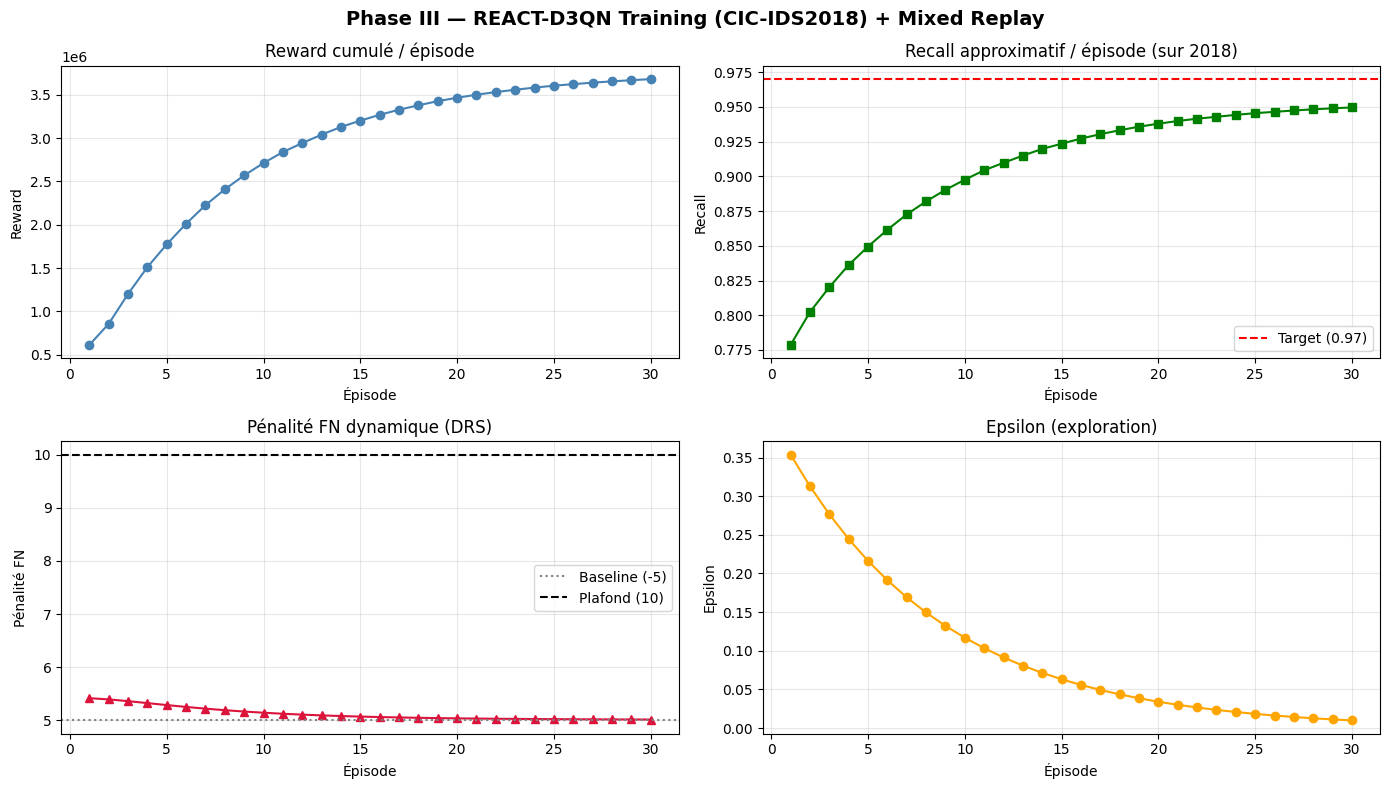

In [13]:
episodes_range = range(1, EPISODES + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Phase III — REACT-D3QN Training (CIC-IDS2018) + Mixed Replay",
             fontsize=14, fontweight='bold')

axes[0, 0].plot(episodes_range, episode_rewards, marker='o', color='steelblue')
axes[0, 0].set_title("Reward cumulé / épisode")
axes[0, 0].set_xlabel("Épisode")
axes[0, 0].set_ylabel("Reward")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(episodes_range, recall_history, marker='s', color='green')
axes[0, 1].axhline(DRS_CONFIG['recall_target'], color='red', ls='--',
                   label=f"Target ({DRS_CONFIG['recall_target']})")
axes[0, 1].set_title("Recall approximatif / épisode (sur 2018)")
axes[0, 1].set_xlabel("Épisode")
axes[0, 1].set_ylabel("Recall")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(episodes_range, penalty_history, marker='^', color='crimson')
axes[1, 0].axhline(DRS_CONFIG['alpha_base'], color='gray', ls=':', label='Baseline (-5)')
axes[1, 0].axhline(DRS_CONFIG['penalty_max'], color='black', ls='--', label='Plafond (10)')
axes[1, 0].set_title("Pénalité FN dynamique (DRS)")
axes[1, 0].set_xlabel("Épisode")
axes[1, 0].set_ylabel("Pénalité FN")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(episodes_range, epsilon_history, marker='o', color='orange')
axes[1, 1].set_title("Epsilon (exploration)")
axes[1, 1].set_xlabel("Épisode")
axes[1, 1].set_ylabel("Epsilon")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/training_phase3.png', dpi=150)
plt.show()

In [14]:
online_net.load_state_dict(torch.load('../models/react_d3qn_2018.pth', map_location=device))
online_net.eval()

y_pred_2018 = []
with torch.no_grad():
    for i in range(0, len(X_test_2018), TEST_BATCH_SIZE):
        batch    = torch.FloatTensor(X_test_2018.iloc[i:i+TEST_BATCH_SIZE].values).to(device)
        preds    = online_net(batch).argmax(dim=1).cpu().numpy()
        y_pred_2018.extend(preds)

y_pred_2018 = np.array(y_pred_2018)
y_true_2018 = y_test_2018.values if hasattr(y_test_2018, 'values') else np.array(y_test_2018)

print("=" * 55)
print("  REACT-D3QN — Résultats sur CIC-IDS2018")
print("=" * 55)
print(classification_report(y_true_2018, y_pred_2018, target_names=['Bénin', 'Attaque']))

cm_2018 = confusion_matrix(y_true_2018, y_pred_2018)
tn, fp, fn, tp = cm_2018.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")

  REACT-D3QN — Résultats sur CIC-IDS2018
              precision    recall  f1-score   support

       Bénin       0.99      0.99      0.99   2678050
     Attaque       0.97      0.95      0.96    549387

    accuracy                           0.99   3227437
   macro avg       0.98      0.97      0.98   3227437
weighted avg       0.99      0.99      0.99   3227437

TN=2,662,883  FP=15,167  FN=24,946  TP=524,441


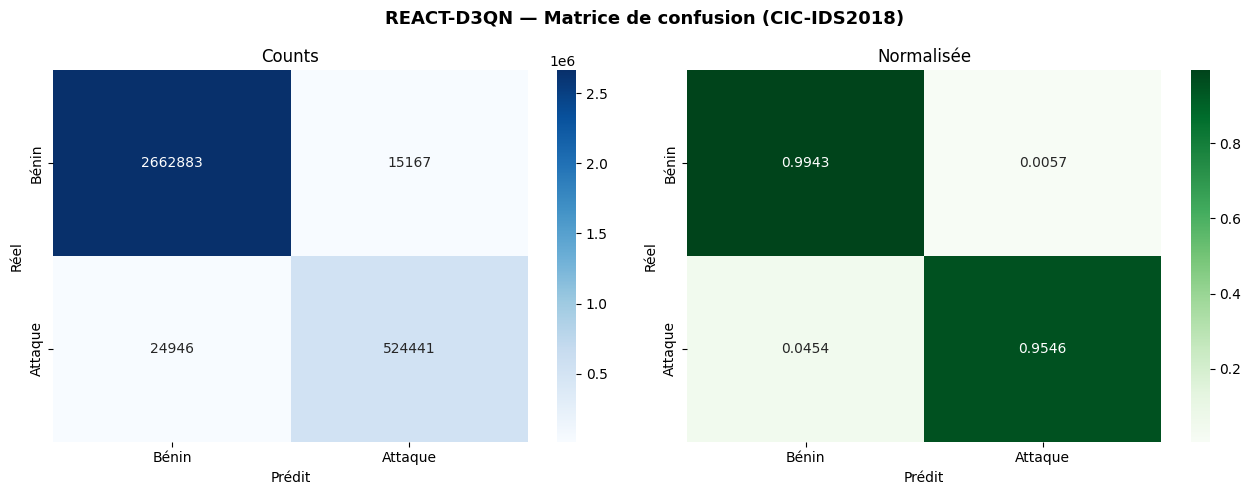

In [15]:
cm_2018_norm = cm_2018.astype(float) / cm_2018.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("REACT-D3QN — Matrice de confusion (CIC-IDS2018)", fontsize=13, fontweight='bold')

sns.heatmap(cm_2018, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Bénin', 'Attaque'], yticklabels=['Bénin', 'Attaque'])
axes[0].set_title("Counts")
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")

sns.heatmap(cm_2018_norm, annot=True, fmt='.4f', cmap='Greens', ax=axes[1],
            xticklabels=['Bénin', 'Attaque'], yticklabels=['Bénin', 'Attaque'])
axes[1].set_title("Normalisée")
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")

plt.tight_layout()
plt.savefig('../figures/confusion_matrix_phase3.png', dpi=150)
plt.show()

In [16]:
df_test_2017  = pd.read_csv('../data/processed/2017/2017_test_scaled.csv')
X_test_2017   = df_test_2017.drop(columns=['Label'])
y_test_2017   = df_test_2017['Label'].values


model_p1 = load_phase1_model('../models/dueling_dqn_2017.pth')
model_p1.eval()
y_pred_p1 = []
with torch.no_grad():
    for i in range(0, len(X_test_2017), TEST_BATCH_SIZE):
        batch = torch.FloatTensor(X_test_2017.iloc[i:i+TEST_BATCH_SIZE].values).to(device)
        y_pred_p1.extend(model_p1(batch).argmax(dim=1).cpu().numpy())
y_pred_p1 = np.array(y_pred_p1)


y_pred_p3 = []
with torch.no_grad():
    for i in range(0, len(X_test_2017), TEST_BATCH_SIZE):
        batch = torch.FloatTensor(X_test_2017.iloc[i:i+TEST_BATCH_SIZE].values).to(device)
        y_pred_p3.extend(online_net(batch).argmax(dim=1).cpu().numpy())
y_pred_p3 = np.array(y_pred_p3)

def get_metrics(y_true, y_pred):
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    rec  = tp / (tp + fn)
    prec = tp / (tp + fp)
    f1   = 2 * rec * prec / (rec + prec + 1e-9)
    return rec, prec, f1, cm

rec_p1, prec_p1, f1_p1, cm_p1 = get_metrics(y_test_2017, y_pred_p1)
rec_p3, prec_p3, f1_p3, cm_p3 = get_metrics(y_test_2017, y_pred_p3)

print("=" * 55)
print("  Catastrophic Forgetting Test (évaluation sur 2017)")
print("=" * 55)
results = pd.DataFrame({
    'Modèle'    : ['Phase I (source)', 'Phase III (après 2018)'],
    'Recall'    : [f"{rec_p1:.4f}",  f"{rec_p3:.4f}"],
    'Precision' : [f"{prec_p1:.4f}", f"{prec_p3:.4f}"],
    'F1-Score'  : [f"{f1_p1:.4f}",  f"{f1_p3:.4f}"],
})
print(results.to_string(index=False))

delta_recall = rec_p3 - rec_p1
delta_f1     = f1_p3  - f1_p1
print(f"\nΔ Recall   : {delta_recall:+.4f}")
print(f"Δ F1-Score : {delta_f1:+.4f}")

if abs(delta_recall) < 0.03:
    print("\n Pas d'oubli catastrophique (Δ Recall < 3%)")
elif delta_recall < -0.05:
    print("\n  Oubli catastrophique détecté")
else:
    print("\n Légère dégradation dans les limites acceptables")

  Catastrophic Forgetting Test (évaluation sur 2017)
                Modèle Recall Precision F1-Score
      Phase I (source) 0.9971    0.9884   0.9928
Phase III (après 2018) 0.9967    0.9880   0.9924

Δ Recall   : -0.0004
Δ F1-Score : -0.0004

 Pas d'oubli catastrophique (Δ Recall < 3%)


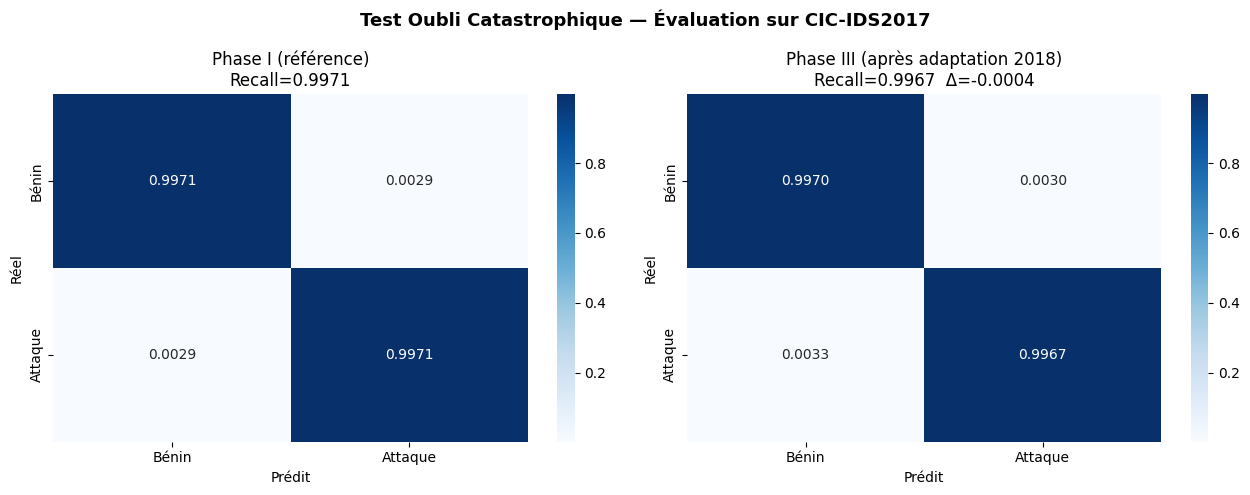

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Test Oubli Catastrophique — Évaluation sur CIC-IDS2017",
             fontsize=13, fontweight='bold')

for ax, cm, title in zip(
    axes,
    [cm_p1, cm_p3],
    [f'Phase I (référence)\nRecall={rec_p1:.4f}',
     f'Phase III (après adaptation 2018)\nRecall={rec_p3:.4f}  Δ={delta_recall:+.4f}']
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.4f', cmap='Blues', ax=ax,
                xticklabels=['Bénin', 'Attaque'], yticklabels=['Bénin', 'Attaque'])
    ax.set_title(title)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.savefig('../figures/forgetting_test_2017.png', dpi=150)
plt.show()

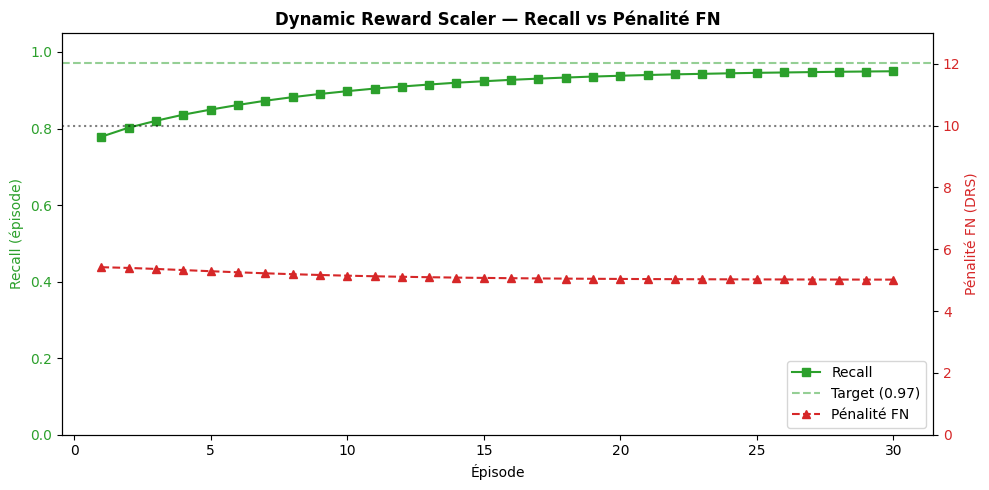

Pénalité initiale : 5.42
Pénalité finale   : 5.02
Recall final      : 0.9496


In [18]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Épisode')
ax1.set_ylabel('Recall (épisode)', color='tab:green')
ax1.plot(episodes_range, recall_history, color='tab:green', marker='s', label='Recall')
ax1.axhline(DRS_CONFIG['recall_target'], color='tab:green', ls='--', alpha=0.5,
            label=f"Target ({DRS_CONFIG['recall_target']})")
ax1.tick_params(axis='y', labelcolor='tab:green')
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.set_ylabel('Pénalité FN (DRS)', color='tab:red')
ax2.plot(episodes_range, penalty_history, color='tab:red', marker='^',
         ls='--', label='Pénalité FN')
ax2.axhline(DRS_CONFIG['penalty_max'], color='black', ls=':', alpha=0.5)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, DRS_CONFIG['penalty_max'] + 3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title("Dynamic Reward Scaler — Recall vs Pénalité FN", fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/drs_analysis.png', dpi=150)
plt.show()

print(f"Pénalité initiale : {penalty_history[0]:.2f}")
print(f"Pénalité finale   : {penalty_history[-1]:.2f}")
print(f"Recall final      : {recall_history[-1]:.4f}")